In [ ]:
import numpy as np
import numpy.linalg as la          # inv, norm, eig, solve, matrix_rank
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)   # tidy array printing
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


In [ ]:
scalar = np.array(2)
vector = np.array([3, 4, 5])
matrix = np.array([[1, 2], [3, 4]])
tensor = np.ones((3, 2, 2))

# .ndim = number of dimensions, .shape = size along each dimension
for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')

scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 2, 2)


In [ ]:
A = np.arange(6).reshape(3,2)   # shape (2, 3)
B = np.ones((3, 2), dtype=int)

print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T:', A.T)
print('A.reshape(2,3):\n', A.reshape(2,3))
print('A.flatten():', A.flatten())

A:
 [[0 1]
 [2 3]
 [4 5]]
A + B (element-wise add):
 [[1 2]
 [3 4]
 [5 6]]
A.T: [[0 2 4]
 [1 3 5]]
A.reshape(2,3):
 [[0 1 2]
 [3 4 5]]
A.flatten(): [0 1 2 3 4 5]


In [ ]:
#🧪 LAB EXERCISE 1 — Tensor ops: add, transpose, reshape
#Using the array T provided below:
#Print its ndim and shape.
#Add T to itself and print the result.
#Transpose T and print the new shape, then reshape T into shape (2, 6).

T = np.arange(12).reshape(3, 4)
print('T:\n', T)

# 1. ndim and shape
print('Dimensions:',T.ndim)
print('Shape:',T.shape)

# 2. T + T
print("Add=T+T:",T+T)

# 3. Transpose (print .T.shape) and reshape to (2, 6)
print('Transpose:',T.T)
print('Reshape:',T.reshape(2,6))

T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Dimensions: 2
Shape: (3, 4)
Add=T+T: [[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]
Transpose: [[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]
Reshape: [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]


In [ ]:
a = np.array([1, 2, 3])
b = np.array([4, 0, 1])
print('a =', a)
print('b =', b)
print('a . b  (dot)   :', np.dot(a, b))      # 1*4 + 2*0 + 3*1 = 7

print('a x b  (cross) :', np.cross(a, b))

a = [1 2 3]
b = [4 0 1]
a . b  (dot)   : 7
a x b  (cross) : [ 2 11 -8]


In [ ]:
print('L2 norm  ||a||_2 :', np.linalg.norm(a))         # sqrt(sum of squares)
print('L1 norm  ||a||_1 :', np.linalg.norm(a, 1))      # sum of absolute values
print('Linf norm        :', np.linalg.norm(a, np.inf)) # max absolute value

# Cosine similarity: the angle between vectors, ignoring magnitude
def cosine(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

print('cosine(a, b)     :', round(cosine(a, b), 3))

L2 norm  ||a||_2 : 3.7416573867739413
L1 norm  ||a||_1 : 6.0
Linf norm        : 3.0
cosine(a, b)     : 0.454


In [ ]:
import numpy as np
import numpy.linalg as la

# Cosine similarity function from previous turn
def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))

pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]

for i, (u, v) in enumerate(pairs, start=1):
    # 1. L1 and L2 norm of u
    u_l1 = la.norm(u, 1)
    u_l2 = la.norm(u)
    print(f"Pair {i} - u L1 norm: {u_l1}, u L2 norm: {u_l2:.4f}")

    # 2. cosine similarity of u and v
    similarity = cosine(u, v)
    print(f"Pair {i} - Cosine Similarity: {similarity:.4f}\n")



Pair 1 - u L1 norm: 2.0, u L2 norm: 1.4142
Pair 1 - Cosine Similarity: 1.0000

Pair 2 - u L1 norm: 6.0, u L2 norm: 3.7417
Pair 2 - Cosine Similarity: 0.7143

Pair 3 - u L1 norm: 2.0, u L2 norm: 2.0000
Pair 3 - Cosine Similarity: 0.0000



In [ ]:

import numpy as np
A = np.array([[2., 1.],
              [1., 3.]])
B = np.array([[1., 0.],
              [4., 2.]])

print('A @ B (matrix multiply):\n', A @ B)
print('A.T   (transpose):\n', A.T)
print('inverse(A):\n', np.linalg.inv(A))
print('trace(A) = sum of diagonal:', np.trace(A))

A @ B (matrix multiply):
 [[ 6.  2.]
 [13.  6.]]
A.T   (transpose):
 [[2. 1.]
 [1. 3.]]
inverse(A):
 [[ 0.6 -0.2]
 [-0.2  0.4]]
trace(A) = sum of diagonal: 5.0


In [ ]:
I = np.eye(2)
print('Identity I:\n', I)
print('A @ inv(A) == I ?', np.allclose(A @ np.linalg.inv(A), I))

print('A symmetric?', np.allclose(A, A.T))
theta = np.radians(30)
Q = np.array([[np.cos(theta), np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print('Q orthogonal?', np.allclose(Q.T @ Q, I))

Identity I:
 [[1. 0.]
 [0. 1.]]
A @ inv(A) == I ? True
A symmetric? True
Q orthogonal? False


In [ ]:
#Exercise-3
#Using matrix M below:
#Print inverse(M) and trace(M).
#Verify that M @ inverse(M) is the identity (use np.allclose).
#Test whether M is symmetric and whether P (provided) is orthogonal.

M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])   # a 90-degree rotation

# 1. inverse and trace of M
print('Inverse:', np.linalg.inv(M))
print('Trace:', np.trace(M))

# 2. M @ inv(M) == I ?
print('M @ inv(M) == I ?', np.allclose(M @ np.linalg.inv(M), I))

# 3. Is M symmetric? Is P orthogonal?
print('M symmetric?', np.allclose(M, M.T))
print('P orthogonal?', np.allclose(P.T @ P, I))


Inverse: [[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
Trace: 7.0
M @ inv(M) == I ? True
M symmetric? True
P orthogonal? True


In [33]:
 #-----------------------------------------------------------
# 🔹 4A. BUILD TRANSFORMATION MATRICES
# -----------------------------------------------------------

# A unit square defined by its 4 corners (each column is a point)
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)

# Scaling matrix: stretch x by 1.5, y by 0.5
S = np.array([[1.5, 0.0],
              [0.0, 0.5]])

# Rotation matrix: rotate by 30 degrees
t = np.radians(30)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])
print("R:",R)
scaled  = S @ square      # apply scaling
rotated = R @ square      # apply rotation
print('Rotated corners:\n', rotated)
print("Scaled:",scaled)




R: [[ 0.866 -0.5  ]
 [ 0.5    0.866]]
Rotated corners:
 [[ 0.     0.866  0.366 -0.5  ]
 [ 0.     0.5    1.366  0.866]]
Scaled: [[0.  1.5 1.5 0. ]
 [0.  0.  0.5 0.5]]


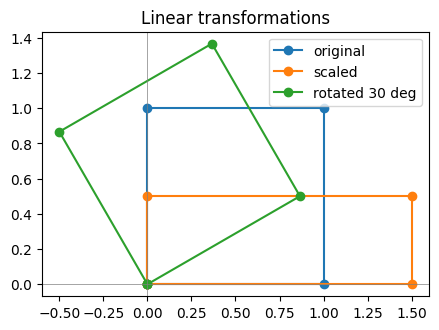

In [34]:
# -----------------------------------------------------------
# 🔹 4B. PLOT ORIGINAL vs TRANSFORMED
# -----------------------------------------------------------

def close_loop(pts):
    # repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 30 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()


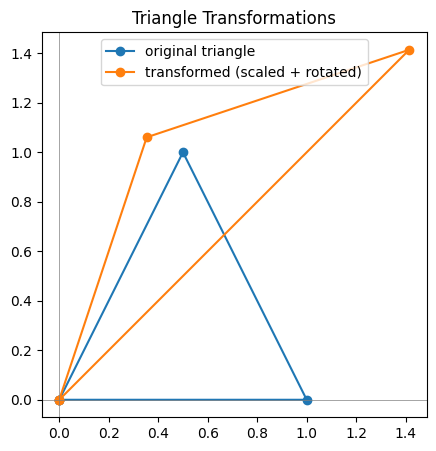

In [38]:
#Execise-4
import numpy as np
import matplotlib.pyplot as plt

tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]], dtype=float)

S = np.array([[2.0, 0.0],
              [0.0, 0.5]])

t = np.radians(45)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

transformed = R @ S @ tri

def close_loop(pts):
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(*close_loop(tri),          marker='o', label='original triangle')
ax.plot(*close_loop(transformed),  marker='o', label='transformed (scaled + rotated)')

ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Triangle Transformations')
plt.show()


In [39]:
# -----------------------------------------------------------
# 🔹 5A. COMPUTE EIGENVALUES & EIGENVECTORS
# -----------------------------------------------------------

A = np.array([[2., 0.],
              [0., 3.]])

vals, vecs = la.eig(A)     # vals = eigenvalues, vecs columns = eigenvectors
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)


# -----------------------------------------------------------
# 🔹 5B. VERIFY  A v = lambda v
# -----------------------------------------------------------

for i in range(len(vals)):
    v = vecs[:, i]                 # i-th eigenvector
    lhs = A @ v                    # A v
    rhs = vals[i] * v              # lambda v
    print(f'lambda={vals[i]:.1f}  A v == lambda v ?', np.allclose(lhs, rhs))


Eigenvalues  (lambda): [2. 3.]
Eigenvectors (columns):
 [[1. 0.]
 [0. 1.]]
lambda=2.0  A v == lambda v ? True
lambda=3.0  A v == lambda v ? True


In [40]:
import numpy as np
import numpy.linalg as la

C = np.array([[4., 1.],
              [2., 3.]])

# 1. eigenvalues and eigenvectors
vals, vecs = la.eig(C)
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)

# 2. print eigenvalues
# (Already printed in the block above, but keeping explicit reference)

# 3. verify A v = lambda v for the first eigenvector
lambda_1 = vals[0]
v_1 = vecs[:, 0]

verification = np.allclose(C @ v_1, lambda_1 * v_1)
print('Verification (C @ v1 == lambda1 * v1):', verification)


Eigenvalues  (lambda): [5. 2.]
Eigenvectors (columns):
 [[ 0.707 -0.447]
 [ 0.707  0.894]]
Verification (C @ v1 == lambda1 * v1): True


In [41]:
# -----------------------------------------------------------
# 🔹 6A. SOLVE A 3x3 SYSTEM  A x = b
# -----------------------------------------------------------

A = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])
b = np.array([8., -11., -3.])

x = la.solve(A, b)
print('Solution x:', x)                    # [2, 3, -1]
print('Rank of A :', la.matrix_rank(A))     # 3 -> full rank
print('Full rank -> a unique solution exists')


# -----------------------------------------------------------
# 🔹 6B. RANK TELLS YOU SOLVABILITY
# -----------------------------------------------------------

# A rank-deficient matrix: row 3 = row 1 + row 2 (not independent)
D = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [5., 7., 9.]])
print('Rank of D:', la.matrix_rank(D), '-> < 3, so rows are dependent')


# -----------------------------------------------------------
# 🔹 6C. COSINE SIMILARITY ON 'EMBEDDINGS'
# -----------------------------------------------------------

# Toy 4-D embeddings (in practice these come from a model)
king  = np.array([0.8, 0.6, 0.1, 0.2])
queen = np.array([0.7, 0.7, 0.1, 0.3])
apple = np.array([0.1, 0.0, 0.9, 0.8])

print('cosine(king, queen):', round(cosine(king, queen), 3))   # high
print('cosine(king, apple):', round(cosine(king, apple), 3))   # low


Solution x: [ 2.  3. -1.]
Rank of A : 3
Full rank -> a unique solution exists
Rank of D: 2 -> < 3, so rows are dependent
cosine(king, queen): 0.986
cosine(king, apple): 0.267


In [43]:
#Exercise-6
A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

# 1. Solve A2 x = b2
x = la.solve(A2, b2)
print('Solution x:', x)

# 2. Rank of A2
rank = la.matrix_rank(A2)
print('Rank of A2:', rank)

# 3. cosine(cat, dog) and cosine(cat, car); which is more similar?
sim_cat_dog = cosine(cat, dog)
sim_cat_car = cosine(cat, car)

print(f'cosine(cat, dog): {sim_cat_dog:.4f}')
print(f'cosine(cat, car): {sim_cat_car:.4f}')



Solution x: [1. 2.]
Rank of A2: 2
cosine(cat, dog): 0.9946
cosine(cat, car): 0.2926
